In [13]:
import numpy as np
import pandas as pd

df = pd.read_csv('interaction_matrix.csv', header=None)
df.shape

(60, 60)

In [14]:
# Check if first row/column are being used as headers
print("Column names:", df.columns.tolist()[:5])  # First 5 column names
print("Index:", df.index.tolist()[:5])  # First 5 index values

Column names: [0, 1, 2, 3, 4]
Index: [0, 1, 2, 3, 4]


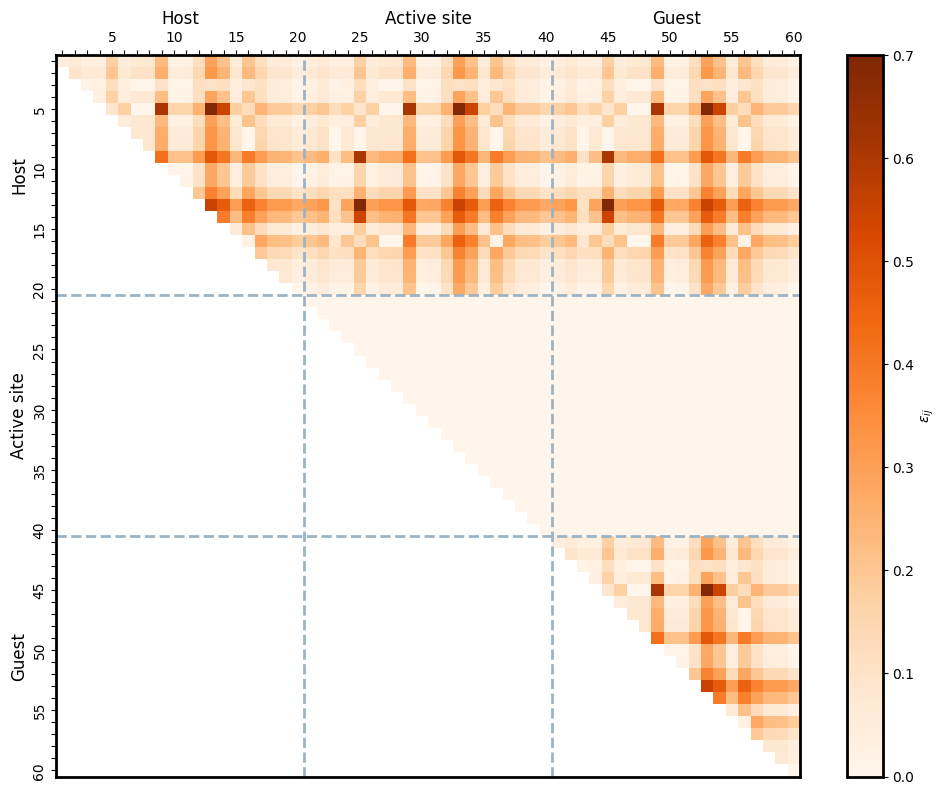

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create labels - show every 5th
labels = [str(i) if i % 5 == 0 else '' for i in range(1, 61)]

# Create heatmap
plt.figure(figsize=(10, 8))
ax = sns.heatmap(df, annot=False, cmap='Oranges', vmin=0.0, vmax=0.7,
                 xticklabels=labels, yticklabels=labels, 
                 cbar_kws={'label': r'$\varepsilon_{ij}$'})
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
# Add vertical line between 20th and 21st cell
ax.axvline(x=20, color="#9ab4c6", linewidth=2, linestyle='--')
ax.axvline(x=40, color='#9ab4c6', linewidth=2, linestyle='--')
ax.axhline(y=40, color='#9ab4c6', linewidth=2, linestyle='--')
ax.axhline(y=20, color='#9ab4c6', linewidth=2, linestyle='--')
# Add border to heatmap
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2)
    spine.set_edgecolor('black')
# Add border to colorbar
cbar = ax.collections[0].colorbar
cbar.outline.set_linewidth(2)
cbar.outline.set_edgecolor('black')

# Add text to inform particle types
ax.text(10, -3, 'Host', color='black', fontsize=12, ha='center', va='center')
ax.text(30, -3, 'Active site', color='black', fontsize=12, ha='center', va='center')
ax.text(50, -3, 'Guest', color='black', fontsize=12, ha='center', va='center')

ax.text(-3, 10, 'Host', color='black', fontsize=12, ha='center', va='center', rotation=90)
ax.text(-3, 30, 'Active site', color='black', fontsize=12, ha='center', va='center', rotation=90)
ax.text(-3, 50, 'Guest', color='black', fontsize=12, ha='center', va='center', rotation=90)

# plt.title('Wang-Frenkel pair interaction strength heatmap')
plt.tight_layout()
# 
plt.savefig('interaction_matrix_heatmap.pdf', dpi=600)